### **Housing Dataset (Regression) — Optimization Plan**
#### Here is the list how optimization tools will be used:
- Distribution and imbalance management.<br> Sampling: SMOTE (Oversampling) I will use it on  classification mushroonm dataset and (QuantileTransformer and RANSAC) on regression dataset.<br>;
- Noise management: MAD - regression housing dataset;
- Overlap management: TomekLinks - classification mushroonm dataset;
- Outlier management: IQR + Isolation Forest - regression housing dataset;

#### In this notebook I will evaluate only optimization tools that will be applied on regression housing dataset.


### **Distribution and imbalance management**
#### Sampling: QuantileTransformer
#### According to Exercise project_1, the housing dataset has many variables with long tail that's why it will be beneficial to use "last ditch  effort" - QuantileTransformer as a samling method. I will check the change of some variables distribution:
- 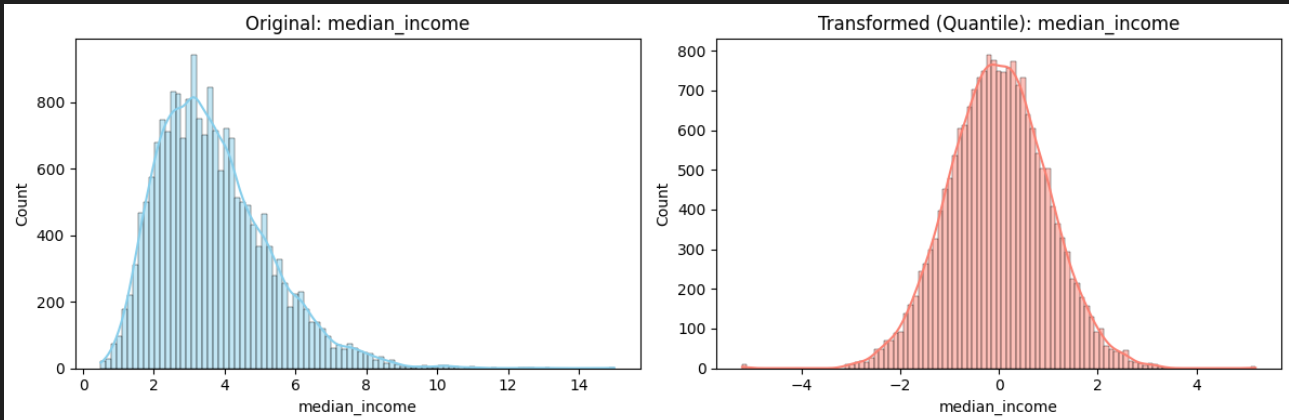
- 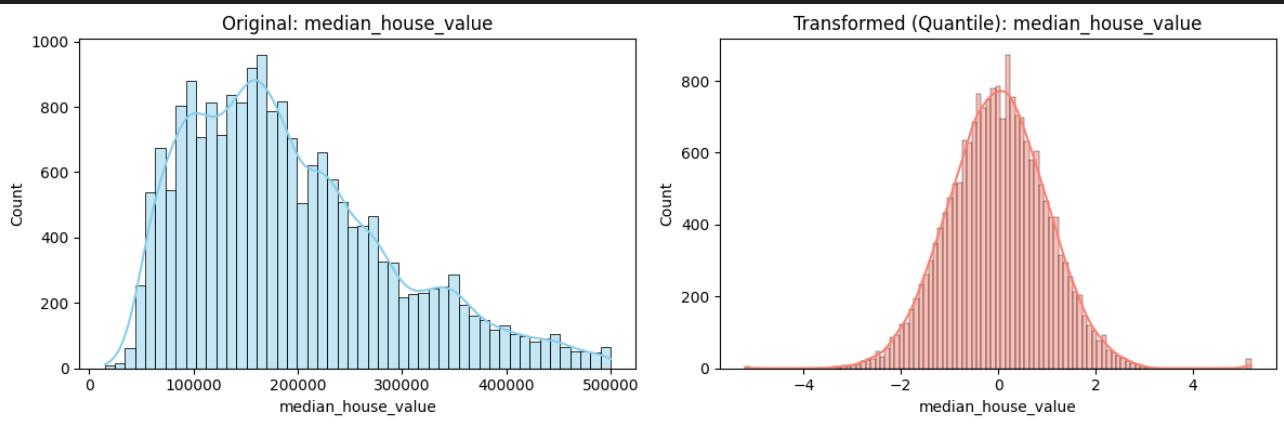
- 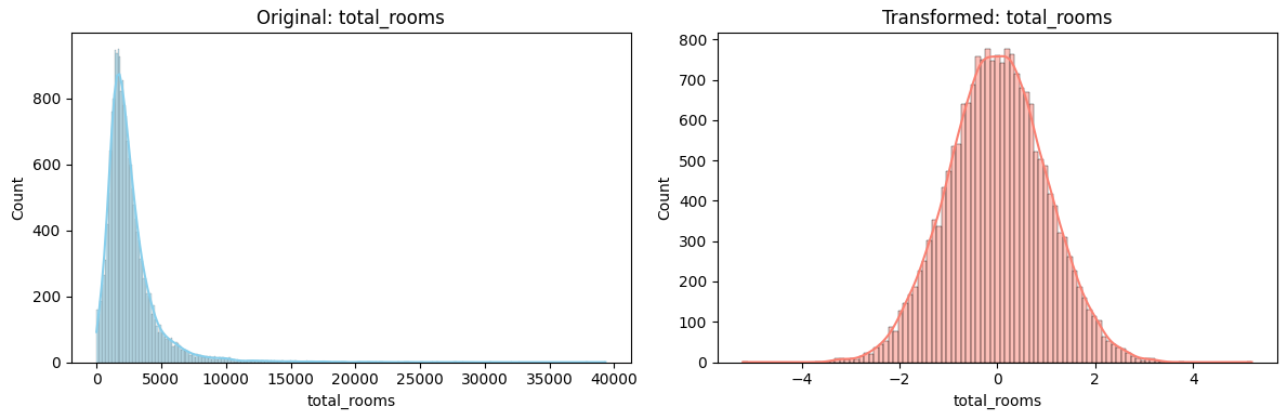
#### Before transformation I deleted rows that have median_house_value 500001 , because all the houses above that value are just marked as 500001. After transformation we can see that distrubution doesn't have long tail.  QuantileTransformer transforms the data based on quantile rank, mapping the values into a normal distribution. With using this aproach we will loose the original numeric values as the transformation preserves ranking order and relative spacing.<br>Result:Transformed variables to a normal distribution. Visual results improved significantly. By using QuantileTransformer we lost original numerical values of the variables, these values were replaced with transformed values. But it keeps the rankings (order) between values. 
#### QuantileTransformer script: Exercise_project_2\Regression_dataset\QuantileTransformer.ipynb<br>
#### RANSAC<br>
#### After applying RANSAC distribution looks much better for "median_income" and "median_house_value"
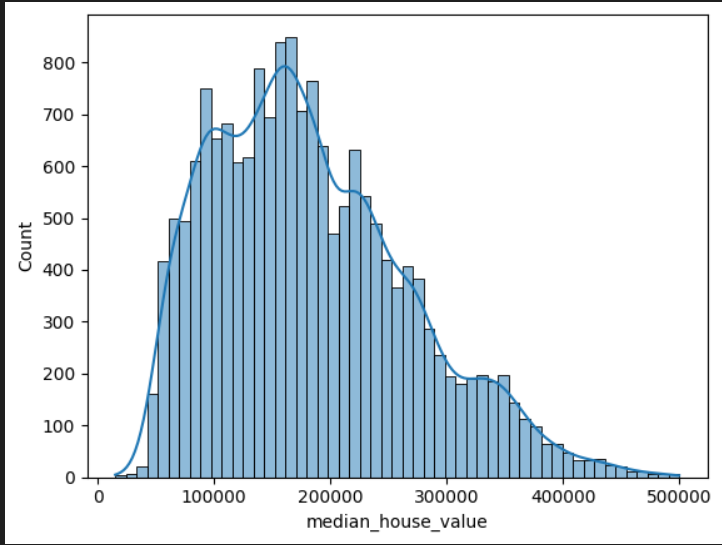<br>
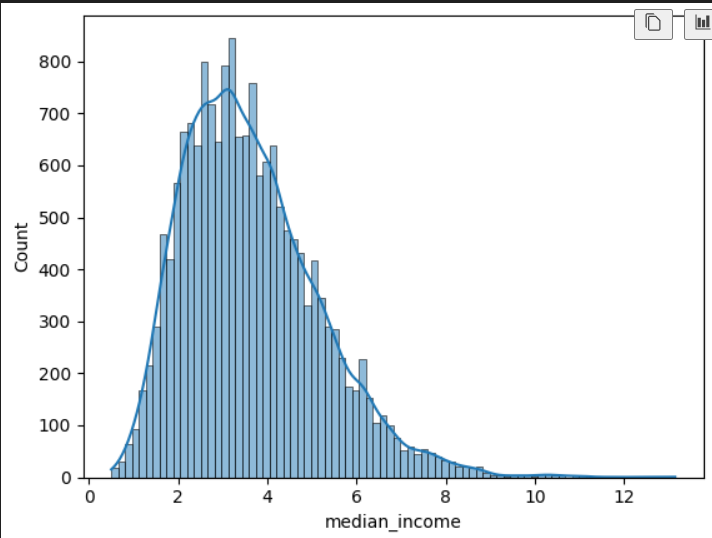<br>
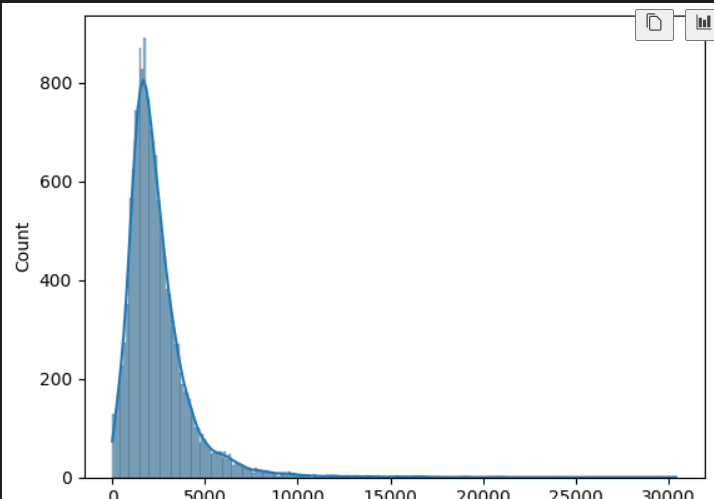<br>
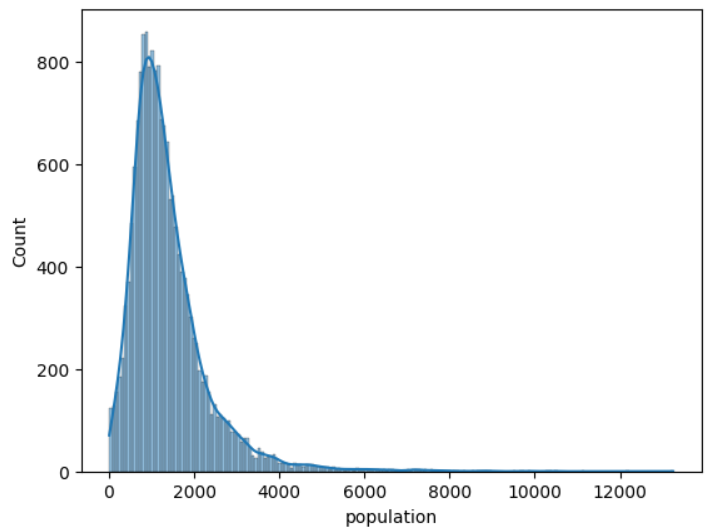<br>
#### Result: RANSAC is not always helpful. For variables: "median_income" and "median_house_value" distribution improves but for "population" and "total_rooms" variables, distribution is still pretty much skewed to the right. <br>Implemented here: Exercise_project_2\Regression_dataset\ransac_regression.ipynb



### **Noise management:**
#### MAD:Variable-wise noise:<br> I have implemented already MAD in Exercise_project_1: Exercise_project_1\Regression_dataset\outlier_and_noise_detection.ipynb<br> I will continue this script to analyse other variables:<br> 
- outliers in variable "median_income_". I applied the threshold of 3.5, that removed extreme values (orange dots on histogram). These outliers are in top.right corner, that has high income, more than 7 and high house values.<br>
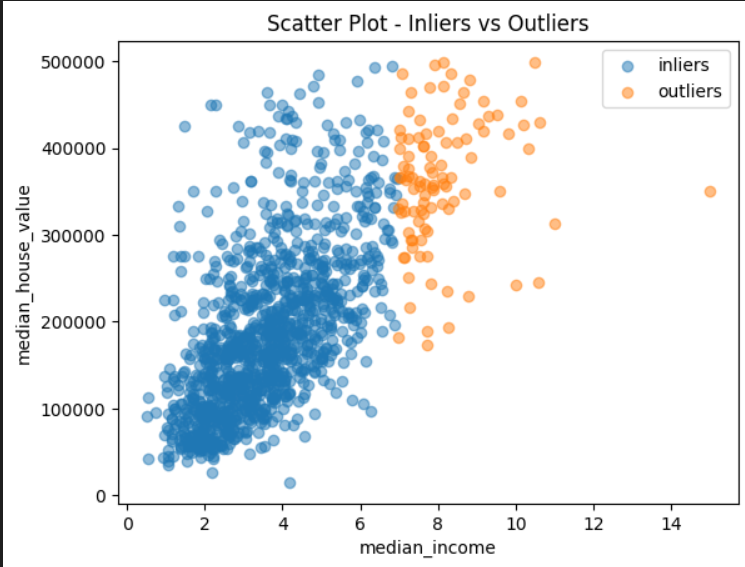<br>
- outliers in "distance_to_nearest_city". Outliers are mostly in the 250–500 km range, so everything that is far from cities. Most of them have low house price.<br>
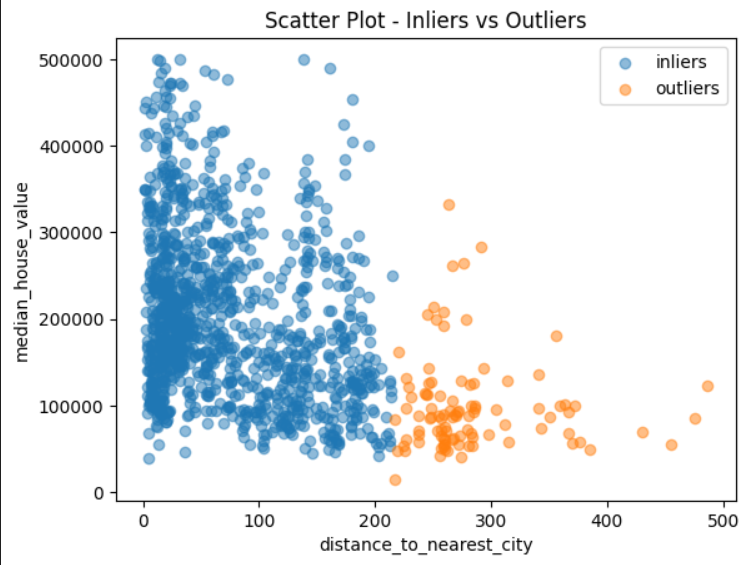<br>
- median_house_value - target variable. Mad considered houses that are close to the city and that have price more than 400K as outliers.<br>
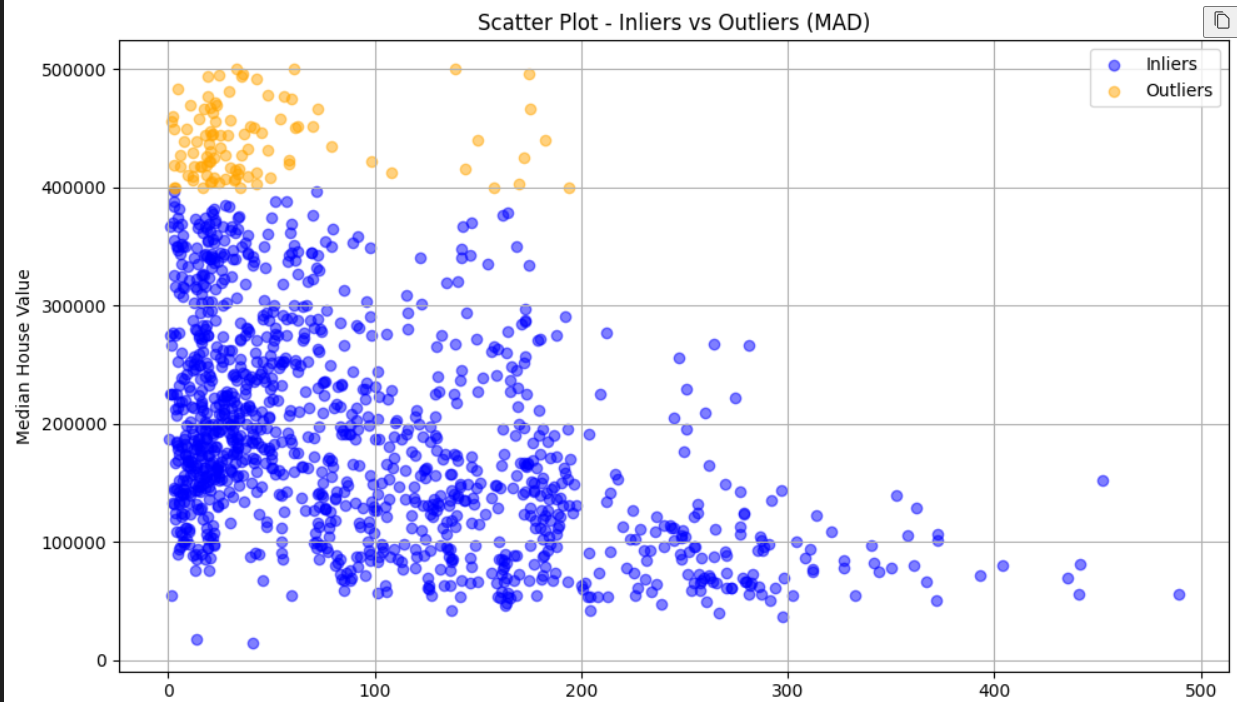<br>
- total_rooms variable. Concentrated in higher values - more than 4500. They are probably flagged as outliers because house value does not aligh with trend to be high. So, even with so high amount of rooms, some houses have low value.<br>
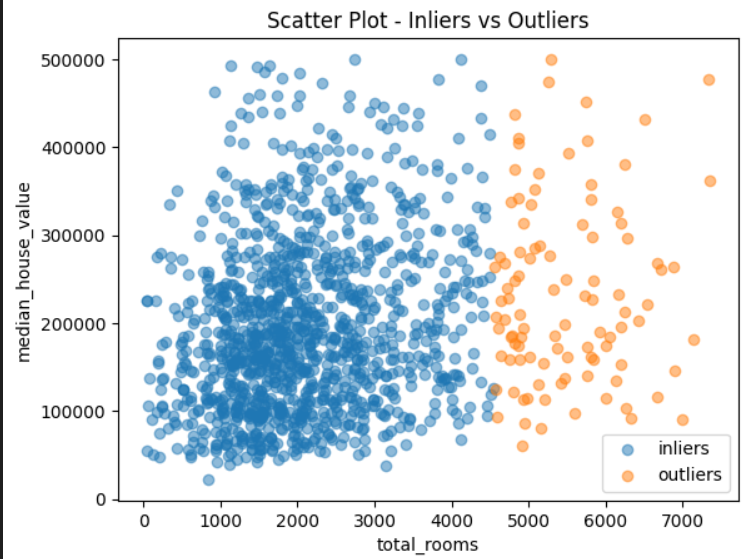<br>
#### Results of MAD method: MAD effectively removed extreme outliers from each variable, visual scatter plots shoed the clear separation of inliers and outliers. MAD was effective when applied to the partially optimized dataset.





### **Outlier management:**
#### IsolationForest wass done in Exercise_project_1 : Exercise_project_1\Regression_dataset\Isolation forest _outliers_detection.ipynb
- Isolation fprest method outcomes: It removed approximately 92 rows out of 18230 of the dataset, including homes with extreme combinations of median_income, distance_to_nearest_city, and median_house_value.
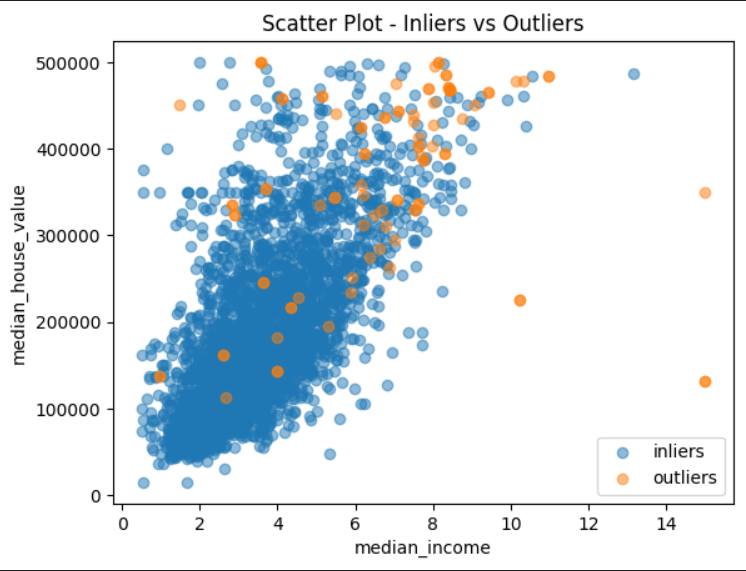<br><br>
- IQR method. This method is typically applied to support variables, not a target. Here is the implementaion of the method:
Ref: https://medium.com/@noorfatimaafzalbutt/outliers-detection-and-removal-using-iqr-method-e629aa8089a8 
#### "Median_income": 343 records removed with value more than about 7.5. These houses have high-income neighborhoods.<br>
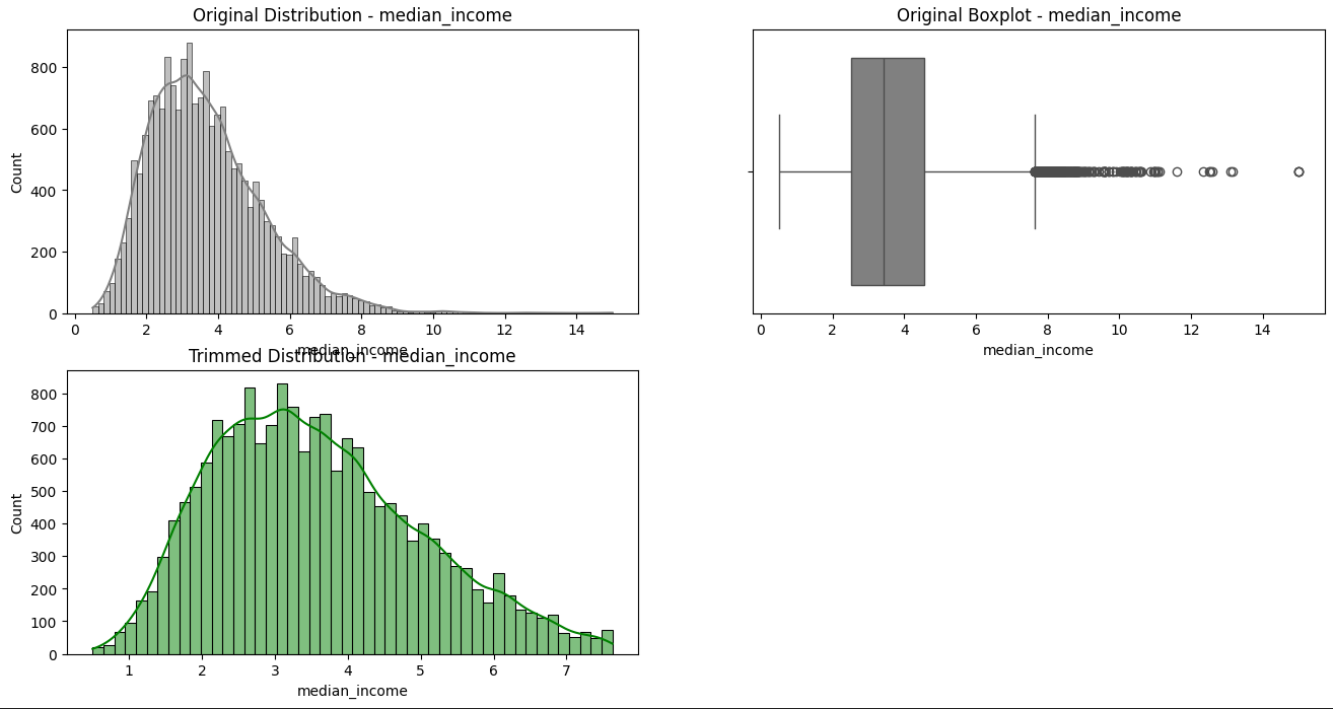<br>
#### "distance_to_nearest_city". Were removed 257 rows, the houses that are very far from cities<br>
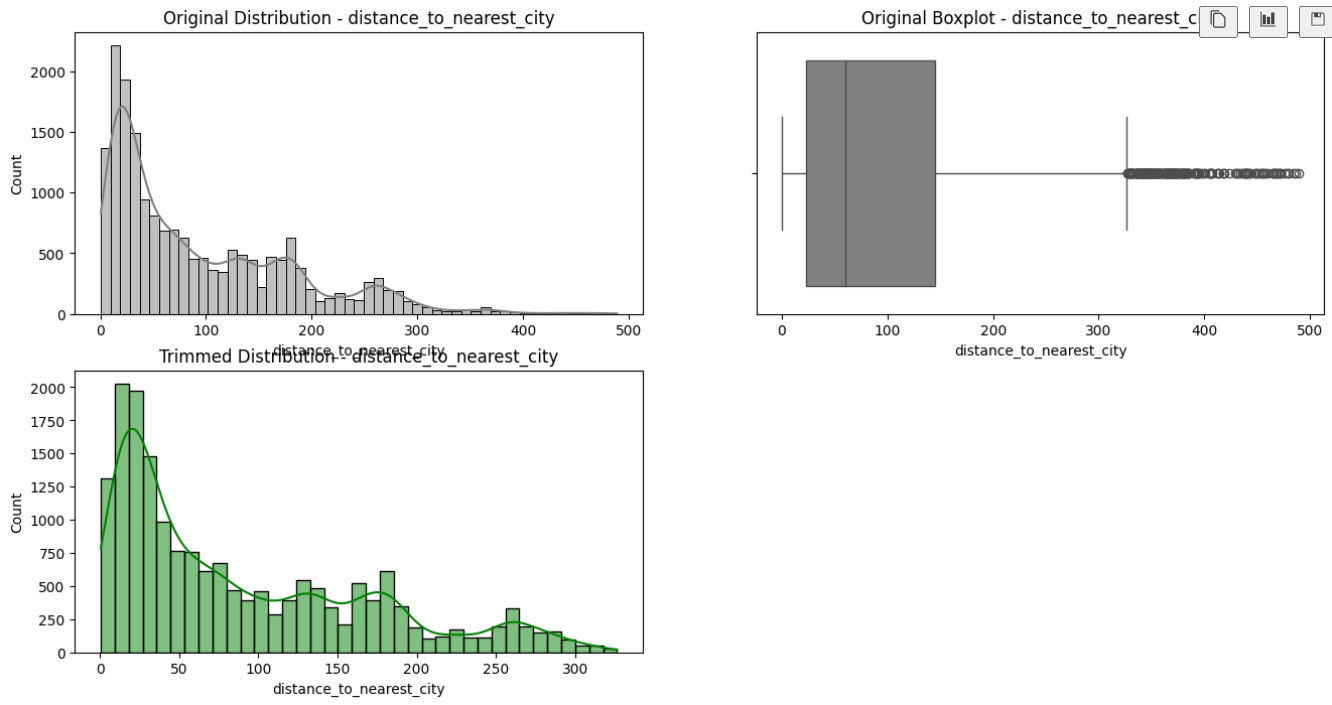<br>
#### housing_median_age - no outliers<br>
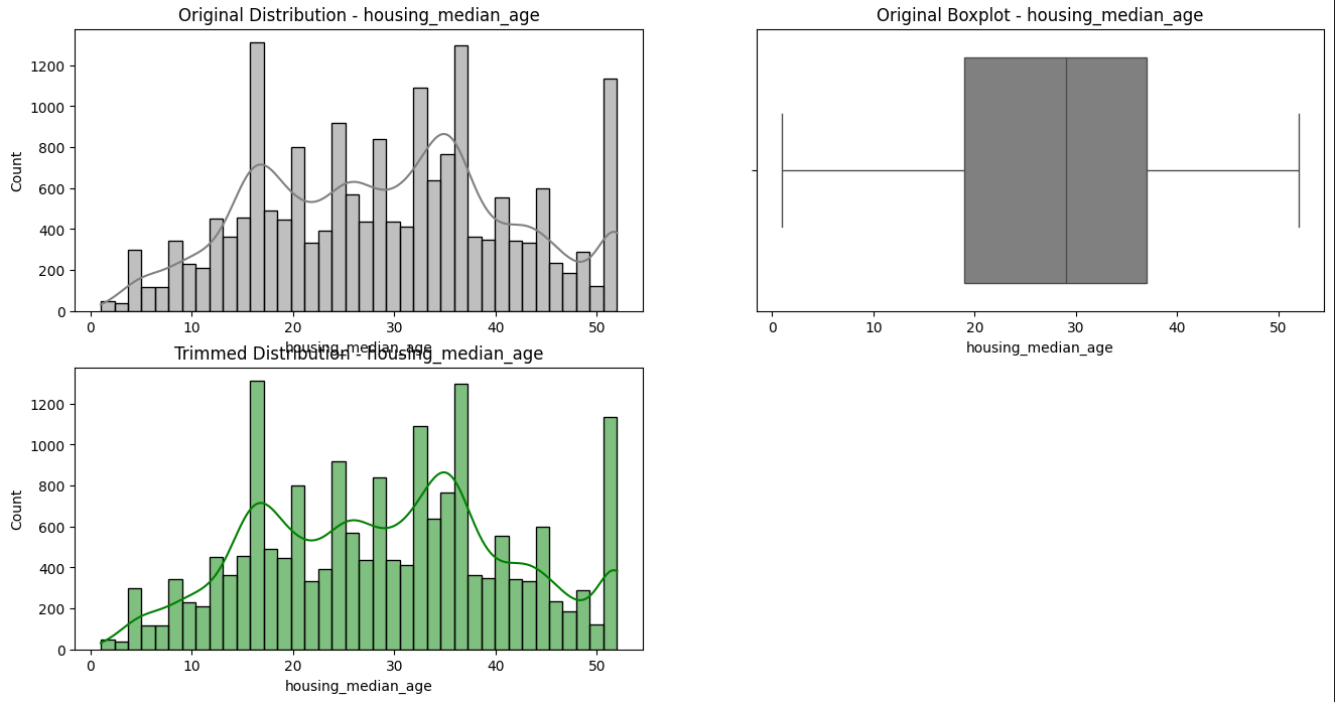<br>
#### "total_rooms". The most rows were removed - 642. Households with more then 5128 rooms. <br>
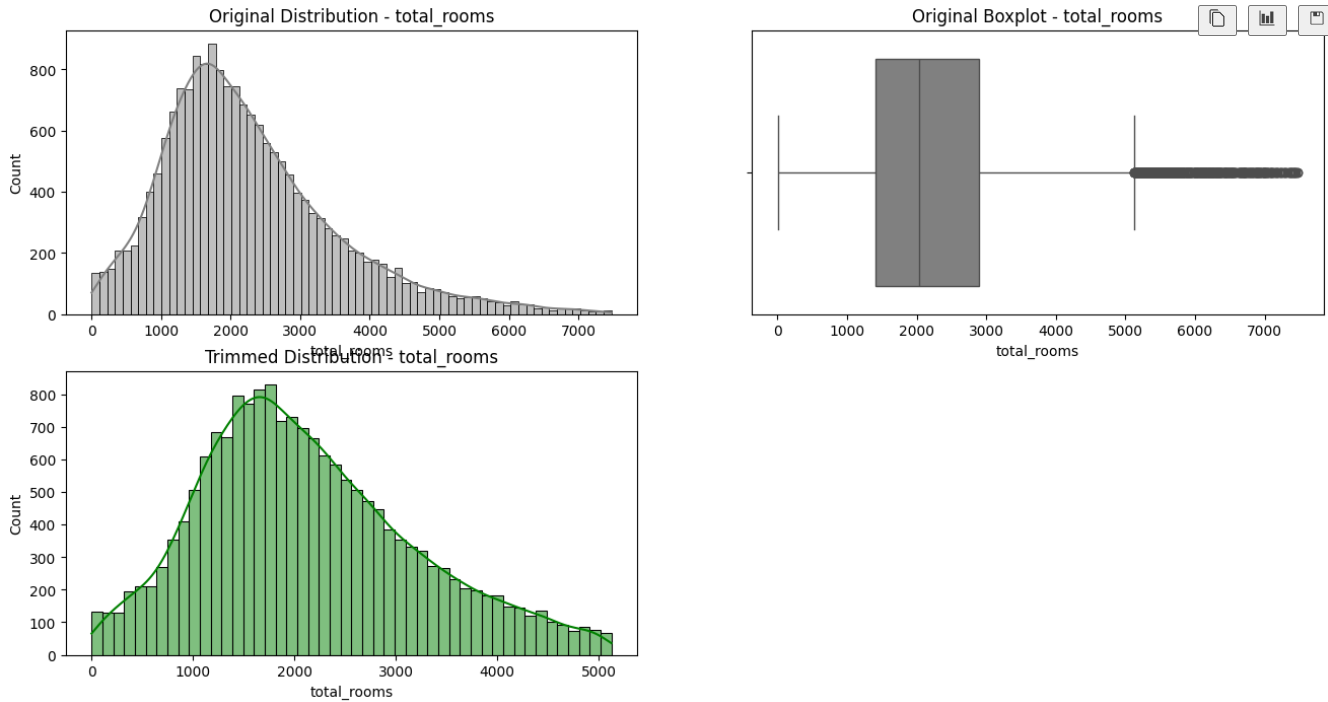<br>
#### These outliers can be removed as percentage is very low or it is possible to implement capping but i think just deleting is fine as the dataset is big - 18322 rows.<br>Results of IQR method: Visualizations showed improvement in distribution. Extreme values were trimmed from right-skewed variables. IQR method removed 1200 rows out of 18322. So, I think this method works well on this dataset. 